# 📊 Dataset Overview

The dataset used in this project is the **Breast Cancer Wisconsin (Diagnostic) Dataset**, commonly used for binary classification using deep learning.

## Key Details:
- Total Samples: **569**
- Total Features: **30 numerical features**
- Target Variable: **Diagnosis**
  - 0 → Benign (Non-cancerous)
  - 1 → Malignant (Cancerous)

## Feature Description:
All features are computed from digitized images of breast mass and describe characteristics of cell nuclei.

The features are grouped into three categories:

### 1. Mean Features (Average values)
radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, compactness_mean, concavity_mean, concave points_mean, symmetry_mean, fractal_dimension_mean

### 2. Standard Error Features (Measurement variation)
radius_se, texture_se, perimeter_se, area_se, smoothness_se, compactness_se, concavity_se, concave points_se, symmetry_se, fractal_dimension_se

### 3. Worst Features (Maximum values)
radius_worst, texture_worst, perimeter_worst, area_worst, smoothness_worst, compactness_worst, concavity_worst, concave points_worst, symmetry_worst, fractal_dimension_worst

## Data Quality:
- No missing values
- All features are numerical
- Clean and structured dataset

## Objective:
To build a **Neural Network (Deep Learning) model** that predicts whether a tumor is benign or malignant.

### import Libraries

In [1]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
df = pd.read_csv('Breast_Cancer_Classification.csv')
df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


### Data Preprocessing

In [3]:
df.shape

(569, 33)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [5]:
df.isna().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [6]:
df.drop(['id', 'Unnamed: 32'], axis = 1, inplace= True)

In [7]:
df.shape

(569, 31)

In [8]:
df.isna().sum()

diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

### Exploratory Data Analysis (EDA)

#### 1) Target Distribution (Cancer vs Non-Cancer)

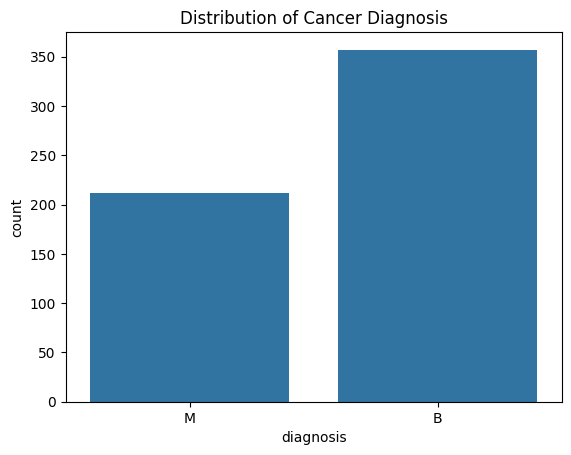

In [9]:
sns.countplot(x='diagnosis', data=df)
plt.title("Distribution of Cancer Diagnosis")
plt.show()

#### Interpretation:
The graph shows the distribution of the target variable (diagnosis). It is observed that benign cases are higher than malignant cases, indicating a slight class imbalance in the dataset. Approximately 63% of the samples are benign, while 37% are malignant. This imbalance may affect model performance, but it is not severe and can be handled effectively.

#### 2) Correlation Heatmap

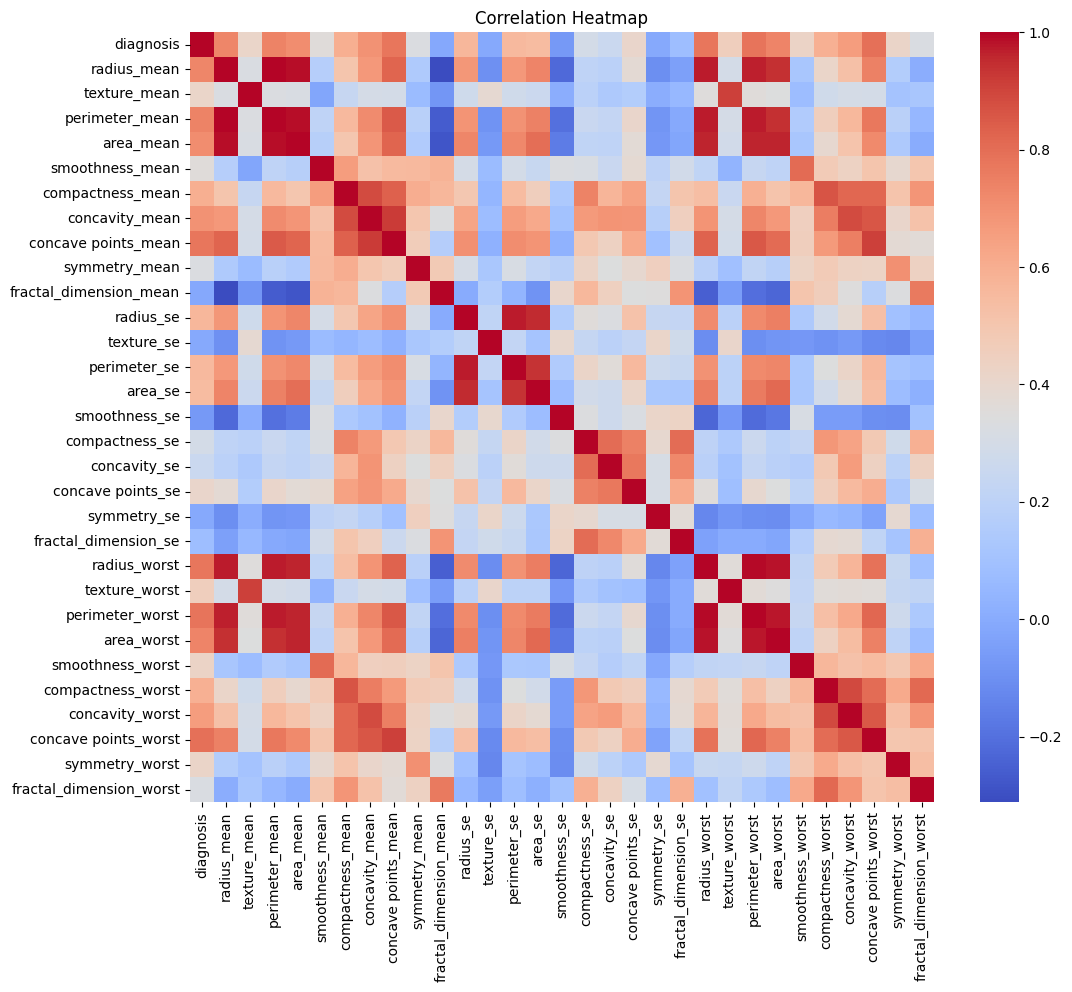

In [10]:
df_temp = df.copy()

# Temporary convert
df_temp['diagnosis'] = df_temp['diagnosis'].map({'M':1, 'B':0})

plt.figure(figsize=(12,10))
sns.heatmap(df_temp.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

#### Interpretation:
- The correlation heatmap shows the relationship between all features in the dataset. It is observed that several features such as radius, perimeter, and area are highly positively correlated, indicating redundancy in the dataset. 
- The target variable (diagnosis) shows strong correlation with features like radius_mean, perimeter_mean, area_mean, concavity_mean, and concave points_mean, suggesting these are important predictors for cancer classification.
- Some features like fractal_dimension and symmetry show weak correlation, indicating lower importance. Overall, the dataset contains multicollinearity, but it can be handled effectively by the neural network model.

#### 3) Top Correlated Features with Target

In [11]:
df_temp = df.copy()

# Temporary convert
df_temp['diagnosis'] = df_temp['diagnosis'].map({'M':1, 'B':0})

corr = df_temp.corr()['diagnosis'].sort_values(ascending=False)
print(corr.head(10))

diagnosis               1.000000
concave points_worst    0.793566
perimeter_worst         0.782914
concave points_mean     0.776614
radius_worst            0.776454
perimeter_mean          0.742636
area_worst              0.733825
radius_mean             0.730029
area_mean               0.708984
concavity_mean          0.696360
Name: diagnosis, dtype: float64


#### 4) Histogram (Feature Distribution)

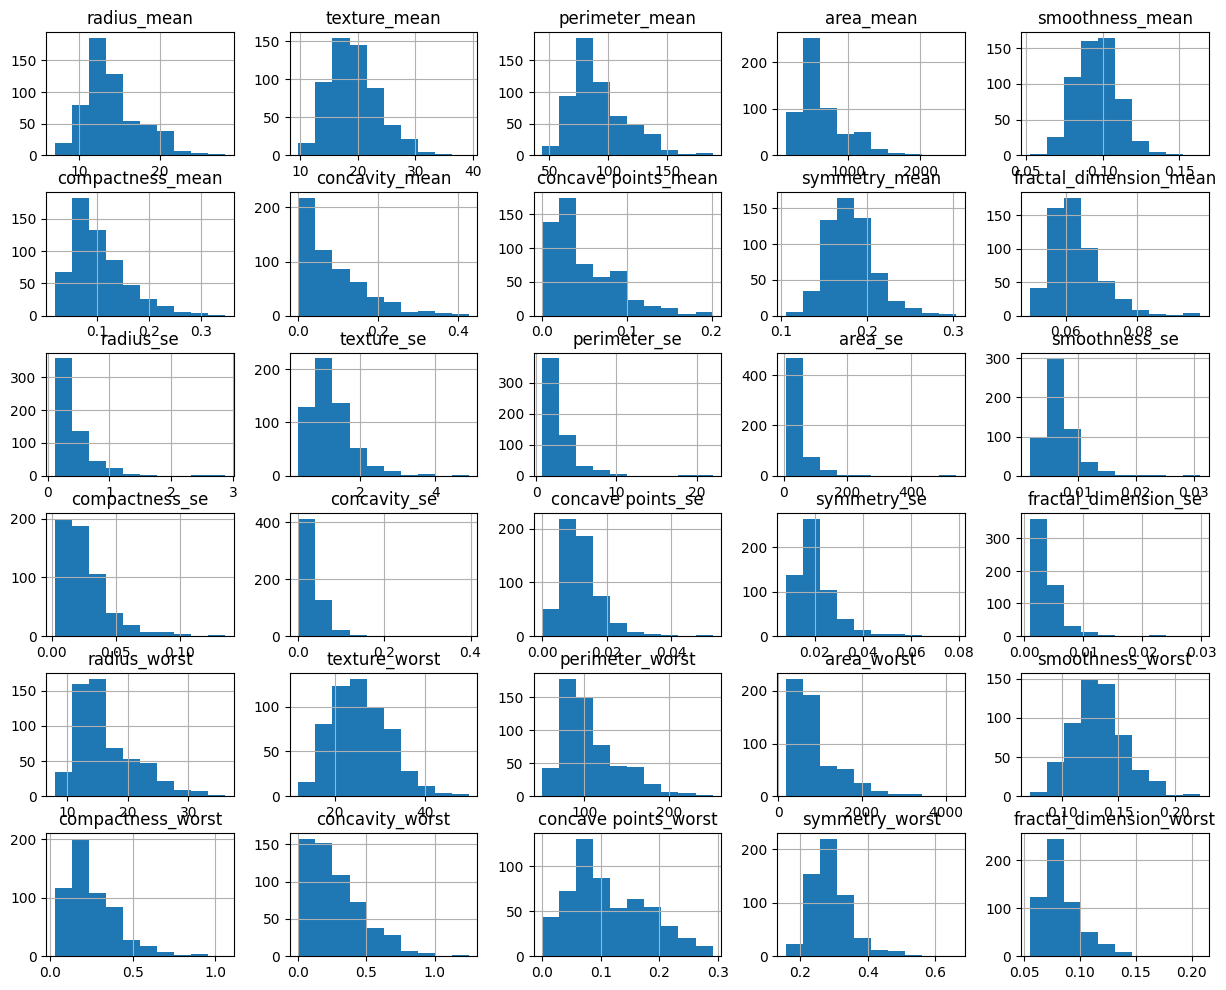

In [12]:
df.hist(figsize=(15,12))
plt.show()

#### Interpretation:
- The distribution plots show that most of the features are positively skewed, indicating that the majority of values lie in the lower range with a few extreme high values (outliers).
- Features such as area, perimeter, and concavity show strong skewness and the presence of outliers. This suggests variability in tumor characteristics.
- Some features like texture and symmetry appear to follow a near-normal distribution, indicating stable behavior.
- Standard error features are highly skewed, showing that most variations are small with a few extreme cases.
- Overall, the dataset contains skewed distributions and outliers, which justifies the need for preprocessing techniques such as scaling and outlier handling.

#### 5) Boxplot (Outlier Detection)

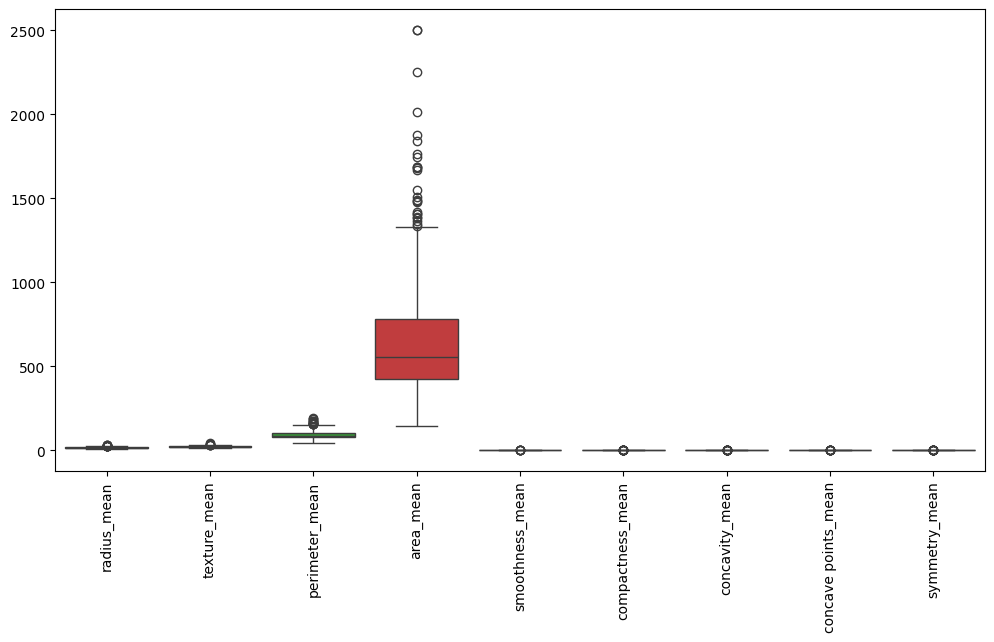

In [13]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df.iloc[:,0:10])
plt.xticks(rotation=90)
plt.show()

#### Interpretation:
- The boxplot shows the presence of outliers across multiple features in the dataset. Features such as area_mean, perimeter_mean, and radius_mean have a wide range and contain significant outliers.
- Area_mean shows the highest variation among all features, indicating that tumor sizes vary greatly across samples.
- Some features like smoothness, compactness, and symmetry have smaller ranges but still contain minor outliers.
- The presence of different scales and outliers highlights the importance of preprocessing techniques such as feature scaling and outlier handling before training the model.

#### 6) Diagnosis vs Mean Radius

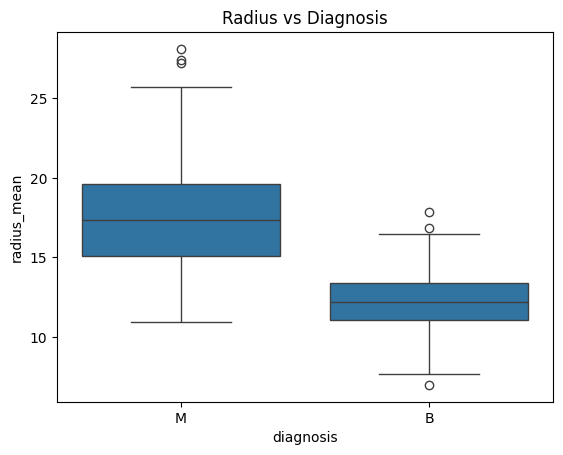

In [14]:
sns.boxplot(x='diagnosis', y='radius_mean', data=df)
plt.title("Radius vs Diagnosis")
plt.show()

#### Interpretation:
- The boxplot shows the relationship between radius_mean and diagnosis. It is observed that malignant tumors have significantly higher radius values compared to benign tumors.
- The median radius for malignant cases is much higher than that of benign cases, indicating that tumor size is an important factor in classification.
- Although there is slight overlap between the two classes, the separation is clearly visible, making radius_mean a strong predictive feature. Outliers in malignant cases indicate extreme tumor sizes.

#### 7) Pairplot

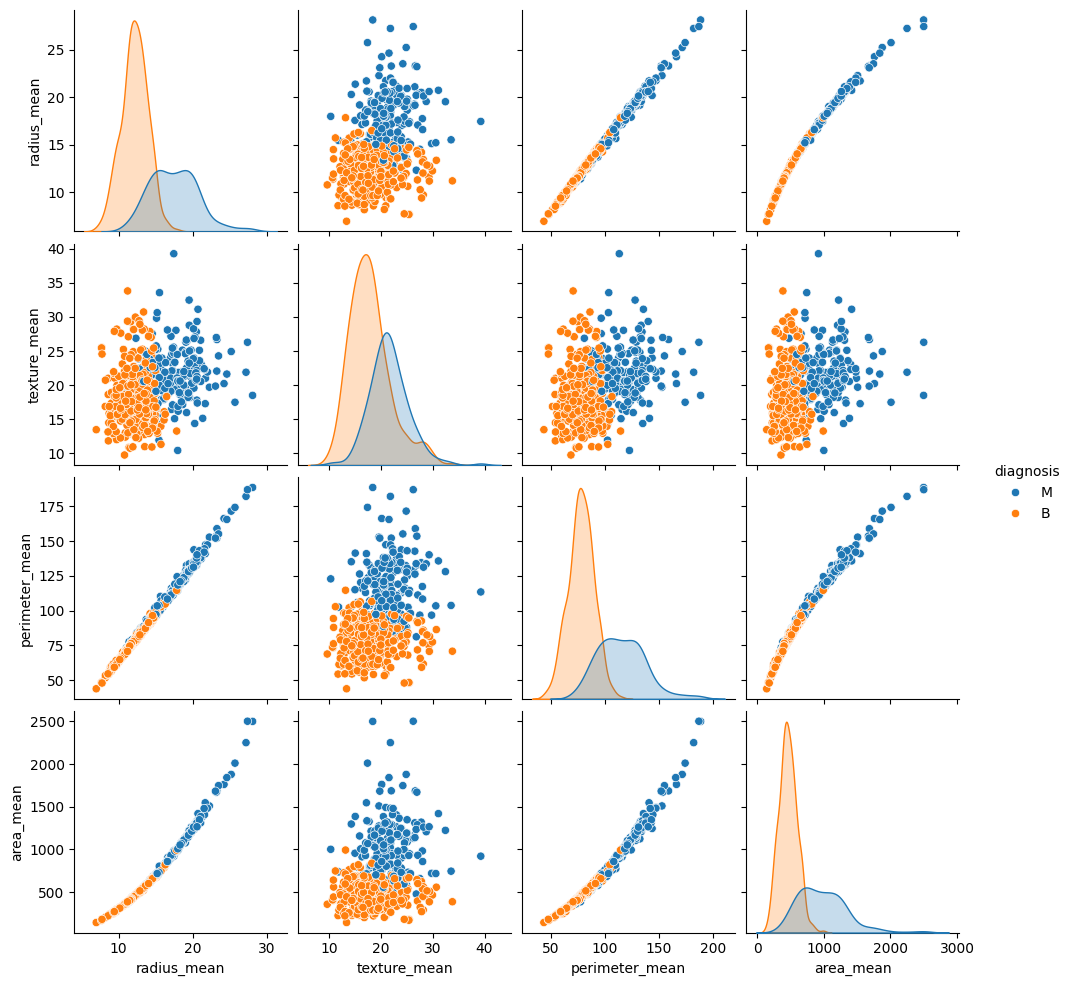

In [15]:
sns.pairplot(df[['radius_mean','texture_mean','perimeter_mean','area_mean','diagnosis']], hue='diagnosis')
plt.show()

#### Interpretation:
- The pairplot shows the relationship between important features and the target variable. Strong linear relationships are observed between radius, perimeter, and area, indicating high correlation among these features.
- Clear class separation is visible between malignant and benign tumors, especially in size-related features such as radius, area, and perimeter. Malignant tumors tend to have higher values, while benign tumors are clustered in lower ranges.
- Some overlap is observed in features like texture, indicating moderate predictive power. Overall, the pairplot confirms that size-related features are strong indicators for classification and that the dataset is well-suited for modeling.

### Outlier Detection and Handling

In [16]:
# Store results
outlier_data = []

# Loop through numeric columns
for col in df.select_dtypes(include=['int64','float64']).columns:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_data.append([col, count])

# Create DataFrame
outlier_df = pd.DataFrame(outlier_data, columns=['Column Name', 'Outliers Count'])

# Sort by outliers
outlier_df = outlier_df.sort_values(by='Outliers Count', ascending=False)

# Reset index properly
outlier_df = outlier_df.reset_index(drop=True)
outlier_df.index = outlier_df.index + 1

# Display result
print(outlier_df)

                Column Name  Outliers Count
1                   area_se              65
2                 radius_se              38
3              perimeter_se              38
4                area_worst              35
5             smoothness_se              30
6            compactness_se              28
7      fractal_dimension_se              28
8               symmetry_se              27
9                 area_mean              25
10  fractal_dimension_worst              24
11           symmetry_worst              23
12             concavity_se              22
13               texture_se              20
14        concave points_se              19
15           concavity_mean              18
16             radius_worst              17
17        compactness_worst              16
18         compactness_mean              16
19          perimeter_worst              15
20   fractal_dimension_mean              15
21            symmetry_mean              15
22              radius_mean     

In [17]:
# Loop through numeric columns
for col in df.select_dtypes(include=['int64','float64']).columns:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Directly modify original df
    df[col] = df[col].clip(lower, upper)

print("Outliers capped in original dataset ✅")

Outliers capped in original dataset ✅


In [18]:
# Check again outliers
outlier_data = []

for col in df.select_dtypes(include=['int64','float64']).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_data.append([col, count])

outlier_df = pd.DataFrame(outlier_data, columns=['Column Name', 'Outliers Count'])
print(outlier_df)

                Column Name  Outliers Count
0               radius_mean               0
1              texture_mean               0
2            perimeter_mean               0
3                 area_mean               0
4           smoothness_mean               0
5          compactness_mean               0
6            concavity_mean               0
7       concave points_mean               0
8             symmetry_mean               0
9    fractal_dimension_mean               0
10                radius_se               0
11               texture_se               0
12             perimeter_se               0
13                  area_se               0
14            smoothness_se               0
15           compactness_se               0
16             concavity_se               0
17        concave points_se               0
18              symmetry_se               0
19     fractal_dimension_se               0
20             radius_worst               0
21            texture_worst     

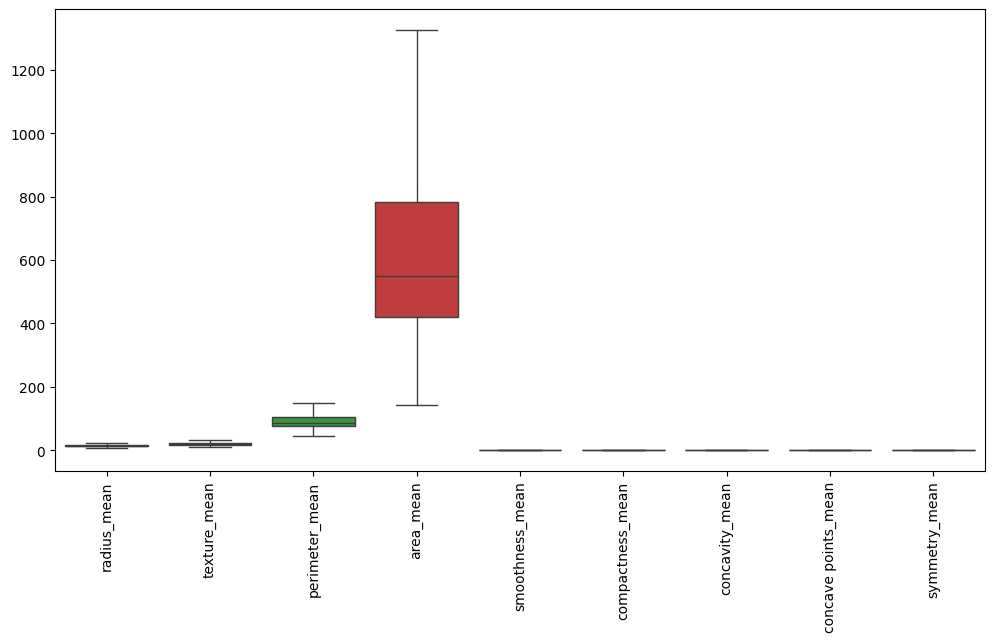

In [19]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df.iloc[:,0:10])
plt.xticks(rotation=90)
plt.show()

#### Interpretation:
- The boxplot compares the distribution of multiple features and highlights significant differences in their scales. Features like area_mean have a much larger range and variability compared to others, indicating that tumor size varies significantly across samples.
- Perimeter and radius also show moderate variation, while features such as smoothness, compactness, and symmetry have very small ranges.
- Outliers are present, especially in area and perimeter features, indicating extreme tumor cases. The large difference in feature scales justifies the use of feature scaling before model training.

### Split Data Into Train and Test

#### STEP 1: Features & Target Split

In [20]:
X = df.drop('diagnosis', axis=1)
y = df['diagnosis'].map({'M':1, 'B':0})

#### STEP 2: Train-Test Split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### Apply Scaling and Train Model

#### STEP 3: Scaling

In [22]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#### STEP 4: Neural Network Model

In [23]:
# base_model
base_model = Sequential()

base_model.add(Dense(16, activation='relu', input_dim=X_train.shape[1]))
base_model.add(Dense(8, activation='relu'))
base_model.add(Dense(1, activation='sigmoid'))

base_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

C:\Users\vsraj\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#### STEP 5: Train Model

In [24]:
history = base_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2
)

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6039 - loss: 0.9419 - val_accuracy: 0.6593 - val_loss: 0.6345
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6093 - loss: 0.6360 - val_accuracy: 0.6703 - val_loss: 0.4774
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6598 - loss: 0.4812 - val_accuracy: 0.7033 - val_loss: 0.4067
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7113 - loss: 0.4190 - val_accuracy: 0.7912 - val_loss: 0.3620
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7692 - loss: 0.4043 - val_accuracy: 0.9011 - val_loss: 0.3237
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8728 - loss: 0.3481 - val_accuracy: 0.9231 - val_loss: 0.2868
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9181 - loss: 0.3030 - val_accuracy: 0.9451 - val_loss: 0.2544
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9265 - loss: 0.2381 - val_accuracy: 0.9451 - val_loss:

#### STEP 6: Evaluate Model

In [25]:
loss, acc = base_model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9815 - loss: 0.0862 
Test Accuracy: 0.9824561476707458


#### STEP 7: Predictions + Confusion Matrix

In [26]:
y_pred = (base_model.predict(X_test) > 0.5).astype(int)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
[[72  0]
 [ 2 40]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        72
           1       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



#### STEP 8: Accuracy Graph

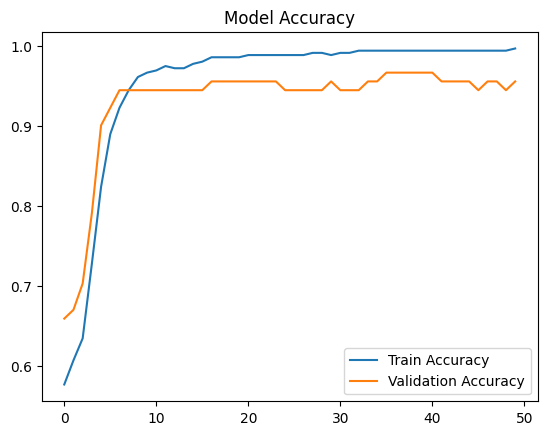

In [27]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Model Accuracy")
plt.show()

#### Interpretation:
- The accuracy graph shows the training and validation performance of the neural network over multiple epochs. The training accuracy increases rapidly and reaches around 99%, indicating that the model has learned the patterns effectively.
- The validation accuracy stabilizes around 96–97%, showing good generalization on unseen data. There is a small gap between training and validation accuracy, indicating slight overfitting, but it is not significant.
- Overall, the model performs well with high accuracy and stable validation performance.

### Apply Advanced Neural Network

#### STEP 1: Advanced Neural Network Model

In [28]:
# advanced_model
advanced_model = Sequential()

advanced_model.add(Dense(32, activation='relu', input_dim=X_train.shape[1]))
advanced_model.add(Dropout(0.3))

advanced_model.add(Dense(16, activation='relu'))
advanced_model.add(Dropout(0.3))

advanced_model.add(Dense(8, activation='relu'))

advanced_model.add(Dense(1, activation='sigmoid'))

advanced_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

C:\Users\vsraj\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#### STEP 2: Early Stopping (Overfitting control 🔥)

In [29]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

#### STEP 3: Train Model

In [30]:
history = advanced_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6226 - loss: 0.6366 - val_accuracy: 0.8681 - val_loss: 0.5395
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7907 - loss: 0.4986 - val_accuracy: 0.9121 - val_loss: 0.3924
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8786 - loss: 0.3739 - val_accuracy: 0.9451 - val_loss: 0.2898
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9129 - loss: 0.2841 - val_accuracy: 0.9341 - val_loss: 0.2230
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9678 - loss: 0.1916 - val_accuracy: 0.9341 - val_loss: 0.1808
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9460 - loss: 0.1769 - val_accuracy: 0.9560 - val_loss: 0.1560
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9353 - loss: 0.1562 - val_accuracy: 0.9560 - val_loss: 0.1463
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9386 - loss: 0.1556 - val_accuracy: 0.9670 - v

#### STEP 4: Evaluate Model

In [31]:
loss, acc = advanced_model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9551 - loss: 0.0929 
Test Accuracy: 0.9736841917037964


#### STEP 5: Confusion Matrix + Report

In [32]:
y_pred = (advanced_model.predict(X_test) > 0.5).astype(int)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
[[71  1]
 [ 2 40]]
              precision    recall  f1-score   support

           0       0.97      0.99      0.98        72
           1       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



#### STEP 6: ROC Curve

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


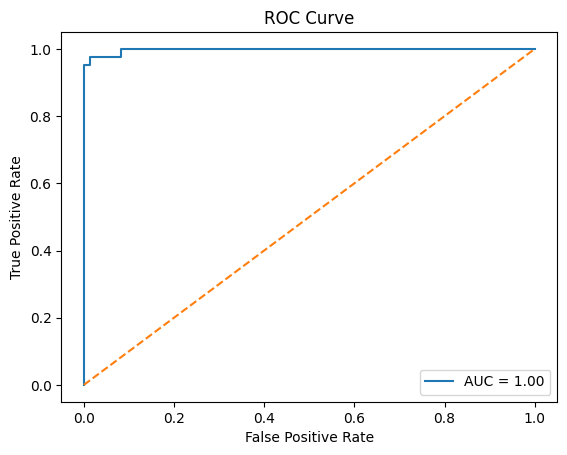

In [33]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = advanced_model.predict(X_test)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = %.2f" % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

#### Interpretation:
- The ROC curve shows the performance of the classification model across different thresholds. The curve is positioned near the top-left corner, indicating a high true positive rate and low false positive rate.
- The AUC (Area Under Curve) score is 1.00, which represents excellent model performance and strong class separation capability.
- The model performs significantly better than a random classifier, as shown by the curve being far above the diagonal line. Overall, the model demonstrates near-perfect classification ability.

#### STEP 7: Accuracy Graph

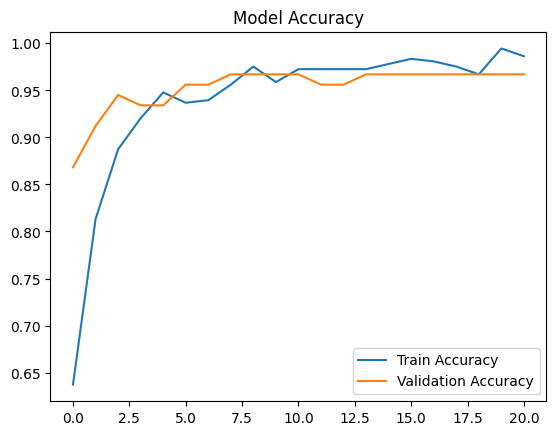

In [34]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Model Accuracy")
plt.show()

#### Interpretation:
- The accuracy graph for the advanced neural network model shows a steady improvement in both training and validation accuracy. The model starts with lower training accuracy but quickly learns and achieves around 98–99% training accuracy.
- The validation accuracy stabilizes around 96–97%, indicating good generalization. The gap between training and validation accuracy is small, suggesting minimal overfitting.
- However, compared to the base model, the advanced model does not provide significant improvement in performance, indicating that increased model complexity did not enhance accuracy.

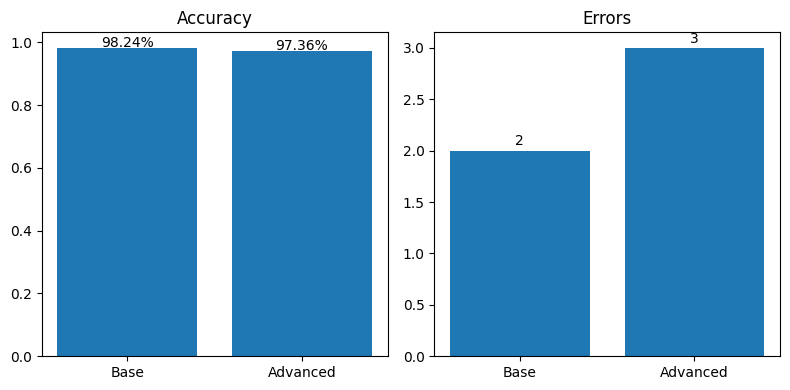

In [35]:
models = ['Base', 'Advanced']
accuracy = [0.9824, 0.9736]
errors = [2, 3]

plt.figure(figsize=(8,4))

# 🔹 Accuracy Plot
plt.subplot(1,2,1)
bars1 = plt.bar(models, accuracy)
plt.title("Accuracy")

# Values on top (in %)
for bar in bars1:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y + 0.001,
             f"{y*100:.2f}%", ha='center')

# 🔹 Errors Plot
plt.subplot(1,2,2)
bars2 = plt.bar(models, errors)
plt.title("Errors")

# Values on top
for bar in bars2:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y + 0.05,
             f"{int(y)}", ha='center')

plt.tight_layout()
plt.show()

#### Interpretation:
- The comparison graph shows that the base model achieves a higher accuracy (98.24%) compared to the advanced model (97.36%). 
- In terms of errors, the base model makes fewer mistakes (2 errors) than the advanced model (3 errors), indicating better performance.
- Despite the increased complexity of the advanced model, it does not outperform the base model. This suggests that a simpler model is sufficient for this dataset and provides better results.

### Summary of Base and Advanced Models

In [36]:
print(base_model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 16)                  │             496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,925 (7.52 KB)

 Trainable params: 641 (2.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,284 (5.02 KB)

None


In [37]:
print(advanced_model.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 32)                  │             992 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,997 (19.52 KB)

 Trainable params: 1,665 (6.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,332 (13.02 KB)

None


### Preparaton for Model Deployment

In [38]:
pip install streamlit pdfplumber pandas scikit-learn tensorflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [39]:
import pickle

# 🔹 Save scaler (IMPORTANT)
pickle.dump(scaler, open('scaler.pkl', 'wb'))

# 🔹 Save base model
base_model.save("base_model.h5")

print("Base model and scaler saved successfully ✅")

Base model and scaler saved successfully ✅
